In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().absolute().parent))


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List
import numpy as np


from src.data_models.caravanify import Caravanify, CaravanifyConfig


---

In [21]:
def extract_source_basins_for_training(
    ca_groups_path: str, source_clusters_path: str, group_mappings: Dict
) -> Dict:
    """
    Extract source basins corresponding to CA target basins grouped by their major groups.

    Args:
        ca_groups_path: Path to CSV file with CA basin group assignments
        source_clusters_path: Path to CSV file with source basin cluster assignments
        group_mappings: Dictionary defining the mapping between groups and clusters

    Returns:
        Dictionary with training data structure organized by target groups
    """
    # Load the data
    ca_groups = pd.read_csv(ca_groups_path)
    source_clusters = pd.read_csv(source_clusters_path)

    training_data = {}

    # Process each group
    for group_key, group_info in group_mappings.items():
        # Get CA basins for this group
        ca_group_basins = ca_groups[
            ca_groups["major_group"] == group_info["ca_group_label"]
        ]["gauge_id"].tolist()

        # Get source basins for this group by cluster
        source_group_basins = source_clusters[
            source_clusters["cluster"].isin(group_info["clusters"])
        ]["gauge_id"].tolist()

        # Split source basins by country
        country_basins = {
            "CH": [basin for basin in source_group_basins if basin.startswith("CH_")],
            "USA": [basin for basin in source_group_basins if basin.startswith("USA_")],
            "CL": [basin for basin in source_group_basins if basin.startswith("CL_")],
        }

        # Store in training data structure
        training_data[group_key] = {
            "target": ca_group_basins,
            "source": country_basins,
        }

        # Print summary statistics
        print(f"{group_key} - CA target basins: {len(ca_group_basins)}")
        for country, basins in country_basins.items():
            print(f"{group_key} - {country} source basins: {len(basins)}")
        print()

    return training_data


def load_data_for_group(
    group_key: str,
    training_data: Dict,
    ca_config: Dict,
) -> Dict:
    """
    Load all data for a specific group using Caravanify.

    Args:
        group_key: Key of the group to load data for (e.g., 'group1')
        training_data: Dictionary with basin mapping information
        ca_config: Configuration for CA data
        ch_config: Configuration for Switzerland data
        usa_config: Configuration for USA data
        cl_config: Configuration for Chile data

    Returns:
        Dictionary with loaded time series and static data
    """
    print(f"Loading data for {group_key}...")

    # Get relevant basin IDs
    ca_basins = training_data[group_key]["target"]

    # Dictionary to store data from each country
    data = {
        "ca_ts_data": None,
        "ca_static_data": None,
    }

    # Load CA data
    ca_caravan_config = CaravanifyConfig(
        attributes_dir=ca_config["ATTRIBUTE_DIR"],
        timeseries_dir=ca_config["TIMESERIES_DIR"],
        gauge_id_prefix=ca_config["GAUGE_ID_PREFIX"],
        use_hydroatlas_attributes=True,
        use_caravan_attributes=True,
        use_other_attributes=True,
    )

    ca_caravan = Caravanify(ca_caravan_config)
    ca_caravan.load_stations(ca_basins)
    data["ca_ts_data"] = ca_caravan.get_time_series()
    data["ca_static_data"] = ca_caravan.get_static_attributes()

    return data

In [51]:
# Configuration for group mappings
group_mappings = {
    "group1": {
        "name": "Group 1 [0, 3]",
        "clusters": [0, 3],
        "ca_group_label": "Group 1 [0, 3]",
    },
    "group2": {
        "name": "Group 2 [0, 2]",
        "clusters": [0, 2],
        "ca_group_label": "Group 2 [0, 2]",
    },
}


# Path configuration
ca_groups_path = "/Users/cooper/Desktop/CAMELS-CH/classification_results/final_basin_assignments_for_12_clusters.csv"
source_clusters_path = "/Users/cooper/Desktop/CAMELS-CH/clustering_results/cluster_assignments12.csv"

# Country configurations
ca_config = {
    "ATTRIBUTE_DIR": "/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/attributes",
    "TIMESERIES_DIR": "/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/timeseries/csv",
    "GAUGE_ID_PREFIX": "CA",
    "MIN_TRAIN_YEARS": 8,
    "VAL_YEARS": 2,
    "TEST_YEARS": 5,
    "MAX_MISSING_PCT": 15,
}

# Step 1: Extract source basins for training
training_data = extract_source_basins_for_training(
    ca_groups_path=ca_groups_path,
    source_clusters_path=source_clusters_path,
    group_mappings=group_mappings
)

# Step 2: Load data for a specific group
group_key = "group2"  # Choose which group to load

group_data = load_data_for_group(
    group_key=group_key,
    training_data=training_data,
    ca_config=ca_config,
)

# Access the loaded data
print(f"CA time series data shape: {group_data['ca_ts_data'].shape}")
print(f"CA static data shape: {group_data['ca_static_data'].shape}")

group1 - CA target basins: 43
group1 - CH source basins: 49
group1 - USA source basins: 99
group1 - CL source basins: 137

group2 - CA target basins: 35
group2 - CH source basins: 71
group2 - USA source basins: 125
group2 - CL source basins: 118

Loading data for group2...
CA time series data shape: (319585, 42)
CA static data shape: (35, 216)


In [52]:
group_data.keys()

dict_keys(['ca_ts_data', 'ca_static_data'])

In [53]:
path_to_csv = "/Users/cooper/Desktop/CAMELS-CH/classification_results/final_basin_assignments_for_12_clusters.csv"

cluster_assignments = pd.read_csv(path_to_csv)
cluster_assignments

# Find gauge_id whose first_choice or second_choice is 3
gauge_ids = cluster_assignments[
    (cluster_assignments["first_choice"] == 3)
]["gauge_id"].tolist()
# Print the gauge_ids
print("Gauge IDs with first_choice as 3:")
for gauge_id in gauge_ids:
    print(gauge_id)
# Print the number of gauge_ids
print(f"Number of gauge IDs with first_choice as 3: {len(gauge_ids)}")

Gauge IDs with first_choice as 3:
CA_15069
CA_15070
CA_15081
CA_15083
CA_15149
CA_15214
CA_15215
CA_16151
CA_16158
CA_16159
CA_16161
CA_16169
CA_16510
CA_17077
Number of gauge IDs with first_choice as 3: 14


(<Figure size 1400x700 with 2 Axes>,
 (<Axes: xlabel='Week of Water Year', ylabel='Temperature (°C)'>,
  <Axes: title={'center': 'Average Water Year Temperature & Precipitation - Gauges: CA_16161'}, ylabel='Precipitation (mm)'>))

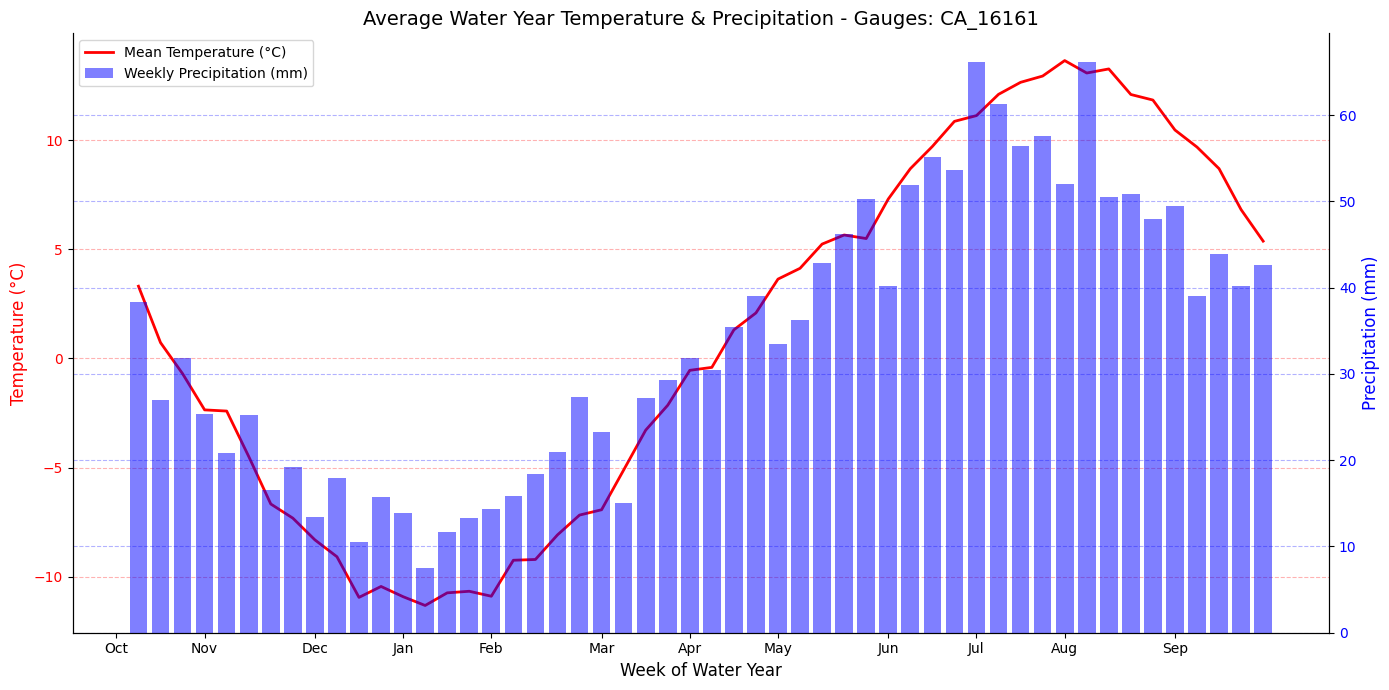

In [ ]:
from typing import Optional, Tuple, Union, List


def plot_water_year_temperature_precipitation(
    df: pd.DataFrame,
    gauge_ids: Union[str, List[str]],
    temp_std_alpha: float = 0.2,
    precip_error: float = 1.0,
) -> Tuple[Optional[plt.Figure], Tuple[Optional[plt.Axes], Optional[plt.Axes]]]:
    """
    Create a plot of temperature and precipitation over the water year with error bands.

    Parameters:
        df: DataFrame with hydrological data
        gauge_ids: Single gauge ID (str) or list of gauge IDs to include
        temp_std_alpha: Alpha value for temperature std deviation area
        precip_error: Error multiplier for precipitation (1.0 = 1 standard deviation)

    Returns:
        fig, (ax1, ax2): Figure and axes objects
    """
    # Ensure gauge_ids is a list
    if isinstance(gauge_ids, str):
        gauge_ids = [gauge_ids]

    # Ensure date column is in datetime format
    df["date"] = pd.to_datetime(df["date"])

    # Filter for the selected gauge IDs
    df = df[df["gauge_id"].isin(gauge_ids)].copy()

    if df.empty:
        print(f"No data found for gauge_ids {gauge_ids}")
        return None, (None, None)

    # Define water year (starting in October)
    df["water_year"] = df["date"].apply(
        lambda x: x.year if x.month < 10 else x.year + 1
    )

    # Compute week of the water year
    df = df.sort_values(["gauge_id", "water_year", "date"])

    # Group by water year and gauge_id, calculate day of water year
    df["start_date"] = df.groupby(["gauge_id", "water_year"])["date"].transform("min")
    df["day_of_water_year"] = (df["date"] - df["start_date"]).dt.days
    df["week"] = (df["day_of_water_year"] // 7) + 1
    df["week"] = df["week"].clip(upper=52)

    # First, calculate weekly means for each gauge_id and water_year
    weekly_data = (
        df.groupby(["gauge_id", "water_year", "week"])
        .agg({"temperature_2m_mean": "mean", "total_precipitation_sum": "sum"})
        .reset_index()
    )

    # Then, for each week, calculate mean across water years for each gauge
    gauge_weekly_avg = (
        weekly_data.groupby(["gauge_id", "week"])
        .agg({"temperature_2m_mean": "mean", "total_precipitation_sum": "mean"})
        .reset_index()
    )

    # Finally, calculate mean and std across gauges for each week
    if len(gauge_ids) > 1:
        # Multiple gauges - calculate std across gauges
        avg_weekly = gauge_weekly_avg.groupby("week").agg(
            {
                "temperature_2m_mean": ["mean", "std"],
                "total_precipitation_sum": ["mean", "std"],
            }
        )
        # Flatten the multi-index columns
        avg_weekly.columns = [f"{col[0]}_{col[1]}" for col in avg_weekly.columns]
        show_error = True
    else:
        # Single gauge - no need for std
        avg_weekly = gauge_weekly_avg.groupby("week").agg(
            {"temperature_2m_mean": "mean", "total_precipitation_sum": "mean"}
        )
        # Add empty std columns
        avg_weekly["temperature_2m_mean_std"] = 0
        avg_weekly["total_precipitation_sum_std"] = 0
        show_error = False

    avg_weekly = avg_weekly.reset_index()

    # Create the plot
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Temperature line plot with std deviation area
    weeks = avg_weekly["week"]
    temp_mean = avg_weekly[
        "temperature_2m_mean_mean" if len(gauge_ids) > 1 else "temperature_2m_mean"
    ]
    temp_std = avg_weekly["temperature_2m_mean_std"].fillna(0)

    ax1.plot(
        weeks,
        temp_mean,
        color="red",
        label="Mean Temperature (°C)",
        linewidth=2,
    )

    # Only show std area if multiple gauges
    if show_error:
        ax1.fill_between(
            weeks,
            temp_mean - temp_std,
            temp_mean + temp_std,
            color="red",
            alpha=temp_std_alpha,
            label="±1 Std Dev Temperature",
        )

    ax1.set_xlabel("Week of Water Year", fontsize=12)
    ax1.set_ylabel("Temperature (°C)", color="red", fontsize=12)
    ax1.tick_params(axis="y", labelcolor="red")
    ax1.set_xticks(np.arange(0, 53, step=4))
    ax1.grid(axis="y", linestyle="--", alpha=0.3, color="red")

    # Precipitation bar chart on secondary axis with error bars
    ax2 = ax1.twinx()
    precip_mean = avg_weekly[
        "total_precipitation_sum_mean"
        if len(gauge_ids) > 1
        else "total_precipitation_sum"
    ]
    precip_std = avg_weekly["total_precipitation_sum_std"].fillna(0)

    bars = ax2.bar(
        weeks,
        precip_mean,
        color="blue",
        alpha=0.5,
        label="Weekly Precipitation (mm)",
        width=0.8,
    )

    # Add error bars only if multiple gauges
    if show_error:
        ax2.errorbar(
            weeks,
            precip_mean,
            yerr=precip_std * precip_error,
            fmt="none",
            color="navy",
            capsize=3,
            label="±1 Std Dev Precipitation",
        )

    ax2.set_ylabel("Precipitation (mm)", color="blue", fontsize=12)
    ax2.tick_params(axis="y", labelcolor="blue")
    ax2.grid(axis="y", linestyle="--", alpha=0.3, color="blue")

    # Add month labels at appropriate week positions
    month_positions = [0, 4, 9, 13, 17, 22, 26, 30, 35, 39, 43, 48]
    month_labels = [
        "Oct",
        "Nov",
        "Dec",
        "Jan",
        "Feb",
        "Mar",
        "Apr",
        "May",
        "Jun",
        "Jul",
        "Aug",
        "Sep",
    ]

    ax1.set_xticks(month_positions)
    ax1.set_xticklabels(month_labels)

    # Add legends for both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2)

    # Title and layout
    title = "Average Water Year Temperature & Precipitation"
    if len(gauge_ids) <= 3:
        title += f" - Gauges: {', '.join(gauge_ids)}"
    else:
        title += f" - {len(gauge_ids)} Gauges"

    plt.title(title, fontsize=14)
    fig.tight_layout()
    sns.despine(top=True, right=False)

    return fig, (ax1, ax2)


gauge_id = "CA_16161"

plot_water_year_temperature_precipitation(group_data["ca_ts_data"], gauge_id)
